<a href="https://colab.research.google.com/github/carolonias-lgtm/Semana-1.1/blob/main/Tarefa4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tarefa 4
Turma: 2°ano de Alimentos
- Carolina Ferreira Onias 16859769
- Luciana Miki Sumi 16885456
- Melissa Rebevhi Santana 17015126

In [32]:
import pandas as pd
f = pd.read_excel("tarefa4.xlsx. (2).xlsx")

In [33]:
import os
os.listdir()

['.config', 'tarefa4.xlsx. (2).xlsx', 'sample_data']

In [34]:
f.shape

(42, 30)

In [35]:
f = pd.read_excel("tarefa4.xlsx. (2).xlsx" ,header=1)

In [36]:
f.head()

,Análise do consumo alimentar pessoal no Brasil,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,"Tabela 3 - Frequência de consumo alimentar, co...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Alimentos e\npreparações,Frequência de consumo alimentar (%),NaN,Consumo alimentar\nmédio per capita\n(g/dia),NaN,Consumo fora do\ndomicílio (% em\nrelação ao t...,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Urbano,Rural,Urbano,Rural,Urbano,Rural,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arroz,75.3,80.9,126.7,158.7,10.4,7.4,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arroz integral,2.6,0.5,3.6,0.9,16.3,10.2,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
f = pd.read_excel("tarefa4.xlsx. (2).xlsx", header=None)

In [38]:
dados = f.iloc[5:, [0, 3]].copy()

In [39]:
dados.columns = ["Alimento", "Consumo alimetar médio per capita (g/dia)_urbano"]

In [40]:
dados.head(39)

,Alimento,Consumo alimetar médio per capita (g/dia)_urbano
5,Arroz,126.7
6,Arroz integral,3.6
7,Preparações à base de arroz,4.8
8,Milho e preparações à base de milho,13.7
9,Feijão,139.3
10,Feijão verde/corda,6.3
11,Preparações à base de feijão,27.1
12,Outras leguminosas,1.1
13,Alface,2.6
14,Couve,1.2


In [41]:
dados = f.iloc[5:, [0, 3]].copy()
dados.columns = ["Alimento", "Consumo_urbano"]
dados.head()
dados["Consumo_urbano"] = pd.to_numeric(
    dados["Consumo_urbano"], errors="coerce"
)
dados = dados.dropna(subset=["Consumo_urbano"])
dados.head()

,Alimento,Consumo_urbano
5,Arroz,126.7
6,Arroz integral,3.6
7,Preparações à base de arroz,4.8
8,Milho e preparações à base de milho,13.7
9,Feijão,139.3


In [42]:
print(f"Primeiro quartil (Q1): {Q1:.2f} g/dia")
print(f"Segundo quartil (Q2 - Mediana): {Q2:.2f} g/dia")
print(f"Terceiro quartil (Q3): {Q3:.2f} g/dia")

Primeiro quartil (Q1): 1.50 g/dia
Segundo quartil (Q2 - Mediana): 3.95 g/dia
Terceiro quartil (Q3): 8.60 g/dia


#Interpretação dos resultados:
- Q1= Aproximadamente 25% dos alimentos analisados apresentam consumo alimentar médio per capita urbano de até 1,50 g/dia.
- Q2= Metade dos alimentos analisados apresenta consumo médio per capita urbano de até 3,95 g/dia, enquanto a outra metade apresenta valores iguais ou superiores a esse valor.
- Q3: Aproximadamente 75% dos alimentos analisados apresentam consumo médio per capita urbano de até 8,60 g/dia, enquanto aproximadamente 25% apresentam valores superiores.

In [43]:
AIQ = Q3 - Q1

print(f"Amplitude interquartílica (AIQ): {AIQ:.2f} g/dia")

Amplitude interquartílica (AIQ): 7.10 g/dia


In [44]:
limite_inferior = Q1 - 1.5 * AIQ

print(f"Limite inferior: {limite_inferior:.2f} g/dia")

Limite inferior: -9.15 g/dia


In [45]:
limite_superior = Q3 + 1.5 * AIQ

print(f"Limite superior: {limite_superior:.2f} g/dia")

Limite superior: 19.25 g/dia


In [46]:
import matplotlib.pyplot as plt

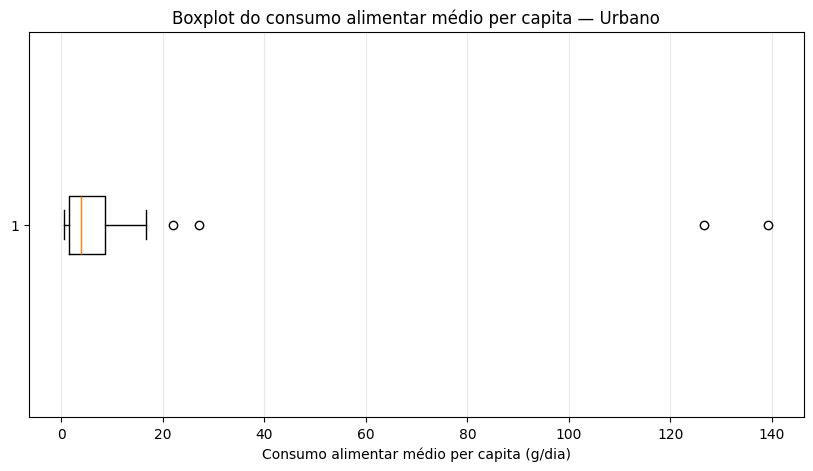

In [53]:
#Boxplot
plt.figure(figsize=(10, 5))

plt.boxplot(dados["Consumo_urbano"], vert=False)

plt.xlabel("Consumo alimentar médio per capita (g/dia)")
plt.title("Boxplot do consumo alimentar médio per capita — Urbano")

plt.grid(axis="x", alpha=0.3)

plt.show()

# Interpretação do box-plot:
-O boxplot mostra que o consumo alimentar médio per capita apresenta uma distribuição assimétrica, com a maior parte dos alimentos concentrada em valores mais baixos. Alguns alimentos apresentam valores de consumo muito superiores aos demais, sendo identificados como observações atípicas.

Esses valores elevados podem representar diferenças reais no padrão de consumo, e não necessariamente erros na base de dados. Alimentos como arroz e feijão, por exemplo, apresentam consumo muito maior que a maioria dos alimentos analisados, o que ajuda a explicar a presença dos valores atípicos no gráfico.

In [52]:
#Dados atipicos
atipicos = dados[
    (dados["Consumo_urbano"] < limite_inferior) |
    (dados["Consumo_urbano"] > limite_superior)
]

atipicos

,Alimento,Consumo_urbano
5,Arroz,126.7
9,Feijão,139.3
11,Preparações à base de feijão,27.1
16,Salada crua,22.0


#Teoria
-**Quartil**: Os quartis são valores que dividem um conjunto de dados ordenados em quatro partes iguais, cada parte contendo 25% dos dados. Essa divisão é feita por três valores que serão identificados por Q1, Q2 e Q3
  - Q1 é chamado de primeiro quartil e separa os dados ordenados de modo que 25% dos dados estejam à sua esquerda e 75%, à sua direita.
  - Q2 é chamado de segundo quartil e é igual à mediana, isto é, 50% dos dados estão à sua esquerda e 50%, à sua direita.
  - Q3 é chamado de terceiro quartil e separa os dados ordenados de modo que 75% dos dados estejam à sua esquerda e 25%, à sua direita.

  -**Intervalo Interquartil**: O intervalo interquartil é a diferença entre o terceiro e o primeiro quar- tis, portanto considera 50% dos dados e não é influenciado pelos valo- res discrepantes, uma vez que os valores discrepantes estão nos 25% das caudas da distribuição.

  # Como determinamos se há observações atípicas em uma base de dados?
-Para determinar se há observações atípicas em uma base de dados, podemos utilizar a regra da amplitude interquartílica (AIQ), que também é utilizada na construção do boxplot. Primeiro, calculamos o primeiro quartil (Q1) e o terceiro quartil (Q3) e, em seguida, calculamos a amplitude interquartílica pela diferença entre eles (AIQ = Q3 − Q1). A partir desse valor, são determinados os limites inferior e superior, utilizando 1,5 vezes a AIQ. Dessa forma, valores menores que o limite inferior ou maiores que o limite superior são considerados observações atípicas. É importante destacar que uma observação atípica não significa necessariamente que o dado esteja errado, mas indica que ele está distante da maior parte dos valores e, por isso, deve ser analisado considerando o contexto da pesquisa.
